In [58]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [60]:
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())

In [61]:
train_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

Input shape: torch.Size([8, 1, 28, 28])
Labels: tensor([8, 8, 2, 9, 8, 0, 0, 3])


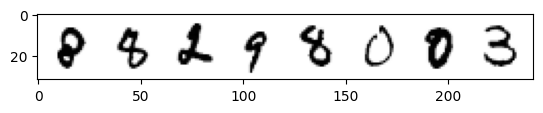

In [62]:
x, y = next(iter(train_dataloader))
print('Input shape:', x.shape)
print('Labels:', y)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='Greys');

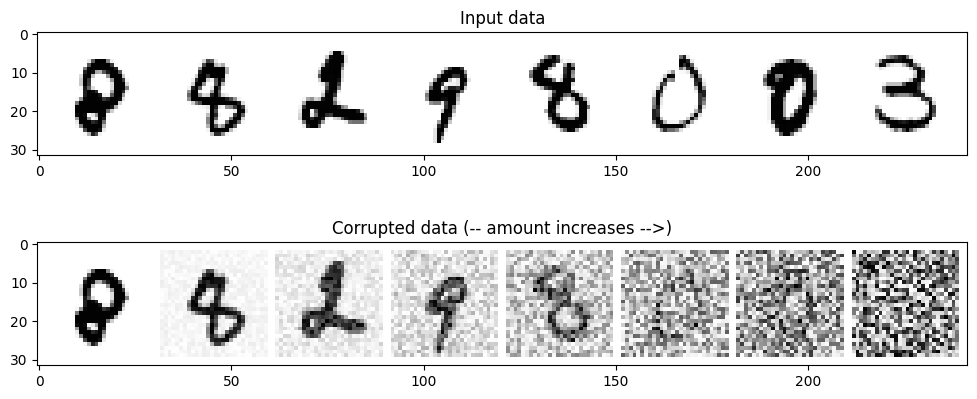

In [63]:
def corrupt(x, amount):
  noise= torch.rand_like(x)
  amount= amount.view(-1, 1, 1, 1)
  return x * (1-amount) + noise * amount

fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap='Greys')

amount = torch.linspace(0, 1, x.shape[0])
noised_x = corrupt(x, amount)

axs[1].set_title('Corrupted data (-- amount increases -->)')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap='Greys');

In [64]:
class BasicUNet(nn.Module):
  def __init__(self, in_channels=1, out_channels=1):
    super().__init__()
    self.down_layers= torch.nn.ModuleList([
        nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
        nn.Conv2d(32, 64, kernel_size=5, padding=2),
        nn.Conv2d(64, 64, kernel_size=5, padding=2)
    ])
    self.up_layers= torch.nn.ModuleList([
        nn.Conv2d(64, 64, kernel_size=5, padding=2),
        nn.Conv2d(64, 32, kernel_size=5, padding=2),
        nn.Conv2d(32, out_channels, kernel_size=5, padding=2)
    ])
    self.act= nn.SiLU()
    self.downscale= nn.MaxPool2d(2)
    self.upscale= nn.Upsample(scale_factor=2)

  def forward(self, x):
    h=[]
    for i,l in enumerate(self.down_layers):
      x=self.act(l(x))
      if i<2:
        h.append(x)
        x= self.downscale(x)
    for i,l in enumerate(self.up_layers):
      if i>0:
        x=self.upscale(x)
        x+=h.pop()
      x=self.act(l(x))
    return x

In [65]:
net = BasicUNet()
x= torch.rand (8, 1, 28, 28)
net(x).shape # output shape

torch.Size([8, 1, 28, 28])

In [66]:
sum([p.numel() for p in net.parameters()]) # parameters of model

309057

In [67]:
batch_size= 128
train_dataloader= DataLoader(dataset, batch_size=batch_size, shuffle=True)

model= BasicUNet()
model.to(device)

BasicUNet(
  (down_layers): ModuleList(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (up_layers): ModuleList(
    (0): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (act): SiLU()
  (downscale): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (upscale): Upsample(scale_factor=2.0, mode='nearest')
)

In [68]:
loss_fn= nn.MSELoss()
optimizer= torch.optim.Adam(model.parameters(), lr=1e-3)

num_epoch= 20
losses=[]

for epoch in range(num_epoch):
  for X, y in train_dataloader:
    X, y= X.to(device), y.to(device)
    noise_amount= torch.rand(X.shape[0]).to(device)
    noisy_x= corrupt(X, noise_amount)

    pred= model(noisy_x)
    loss= loss_fn(pred, X)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
  avg_loss= sum(losses[-len(train_dataloader):])/len(train_dataloader)
  print(f"Epoch {epoch+1}:\nloss: {avg_loss}")
  print("-"*50)

Epoch 1:
loss: 0.028617018734468327
--------------------------------------------------
Epoch 2:
loss: 0.021197779773315516
--------------------------------------------------
Epoch 3:
loss: 0.019053830201231213
--------------------------------------------------
Epoch 4:
loss: 0.018016709296751632
--------------------------------------------------
Epoch 5:
loss: 0.017521286700993205
--------------------------------------------------
Epoch 6:
loss: 0.01715115361265155
--------------------------------------------------
Epoch 7:
loss: 0.01667884802783349
--------------------------------------------------
Epoch 8:
loss: 0.016717326896848964
--------------------------------------------------
Epoch 9:
loss: 0.01632665581048043
--------------------------------------------------
Epoch 10:
loss: 0.016167098076454105
--------------------------------------------------
Epoch 11:
loss: 0.015922229314075987
--------------------------------------------------
Epoch 12:
loss: 0.015739814670228246
-------

Text(0, 0.5, 'Loss')

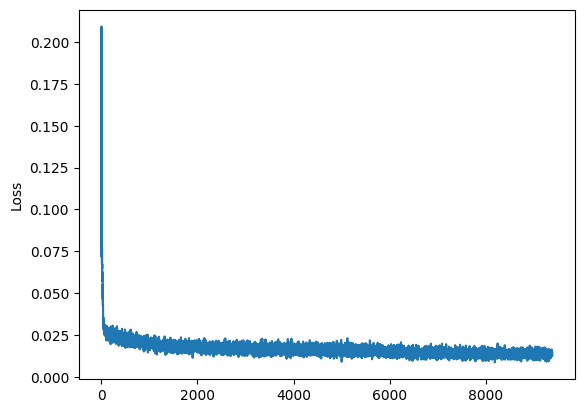

In [69]:
plt.plot(losses)
plt.ylabel('Loss')
# plt.ylim(0, 0.1)

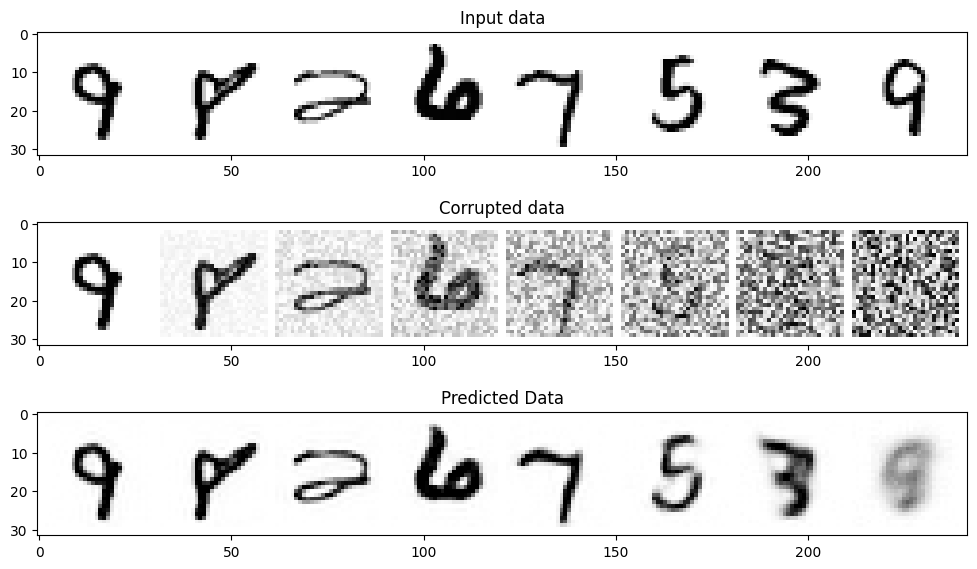

In [70]:
x,y = next(iter(train_dataloader))
x= x[:8]

amount= torch.linspace(0, 1, x.shape[0])
noised_x= corrupt(x, amount)

with torch.no_grad():
  preds = model(noised_x.to(device)).detach().cpu()


fig, axs = plt.subplots(3, 1, figsize=(12, 7))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0].clip(0, 1), cmap='Greys')
axs[1].set_title('Corrupted data')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0].clip(0, 1), cmap='Greys')
axs[2].set_title('Predicted Data')
axs[2].imshow(torchvision.utils.make_grid(preds)[0].clip(0, 1), cmap='Greys')

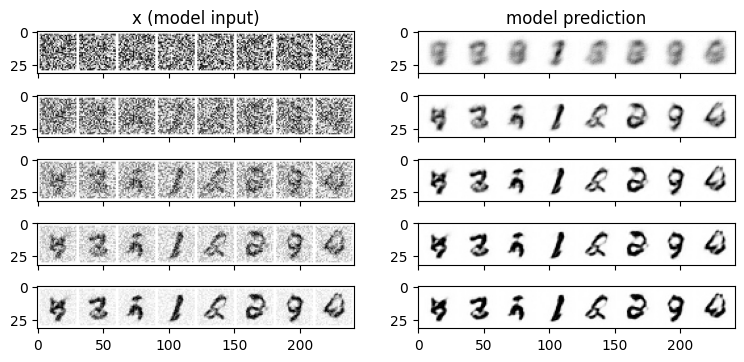

In [71]:
n_steps= 5
x= torch.rand(8,1,28,28).to(device)
step_history= [x.detach().cpu()]
pred_output_history= []

for step in range(n_steps):
  with torch.no_grad():
    pred= model(x)
  pred_output_history.append(pred.detach().cpu())

  mix_factor= 1/(n_steps - step)
  x= x* (1- mix_factor) + pred * mix_factor
  step_history.append(x.detach().cpu())

fig, axs = plt.subplots(n_steps, 2, figsize=(9, 4), sharex=True)
axs[0,0].set_title('x (model input)')
axs[0,1].set_title('model prediction')
for i in range(n_steps):
    axs[i, 0].imshow(torchvision.utils.make_grid(step_history[i])[0].clip(0, 1), cmap='Greys')
    axs[i, 1].imshow(torchvision.utils.make_grid(pred_output_history[i])[0].clip(0, 1), cmap='Greys')

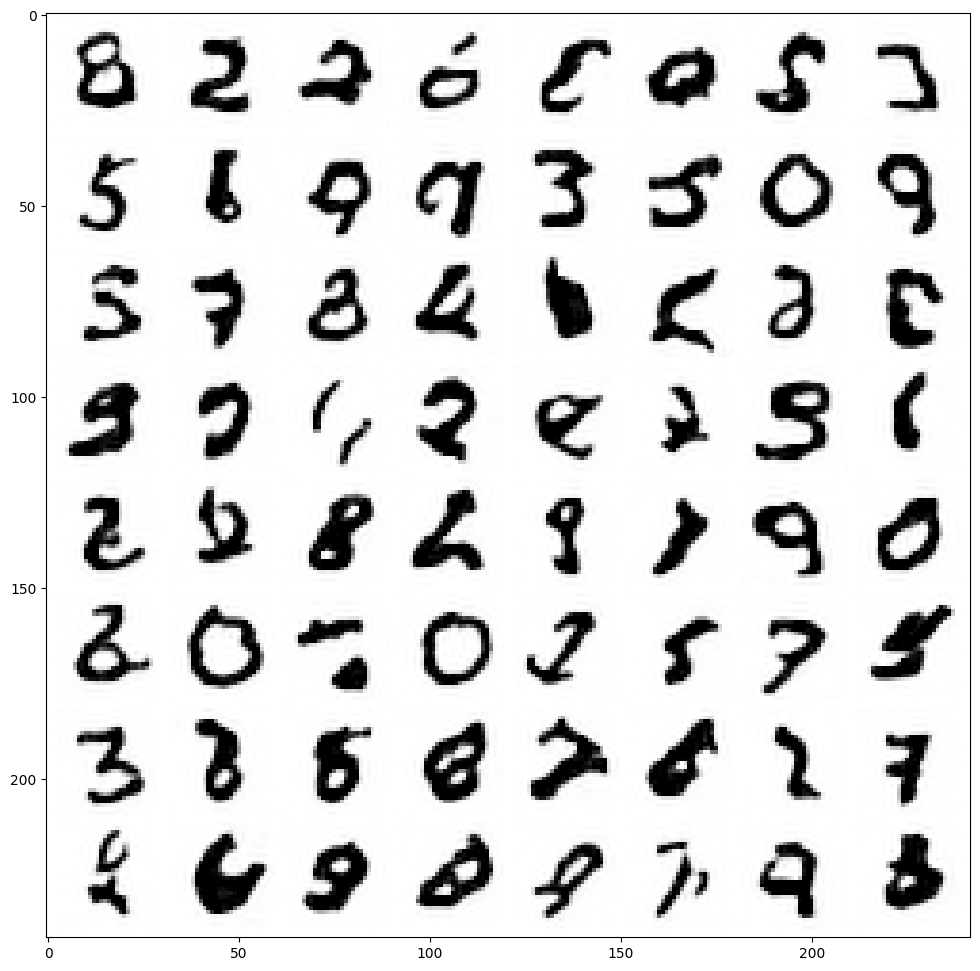

In [72]:
n_steps = 40
x = torch.rand(64, 1, 28, 28).to(device)
for i in range(n_steps):
  noise_amount = torch.ones((x.shape[0], )).to(device) * (1-(i/n_steps)) # Starting high going low
  with torch.no_grad():
    pred = model(x)
  mix_factor = 1/(n_steps - i)
  x = x*(1-mix_factor) + pred*mix_factor
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1), cmap='Greys')